Saving student_data.csv to student_data.csv
MSE:  4.166563708144214
MAE:  1.2655778314113377
R2:  0.7968030186093205
weights: -0.04800003558076944
bias: 10.325949367088608
prediction:  [ 7.26473656 12.23569044  3.39563375  8.19979213  8.36658762 12.83715501
 18.96744961  6.38149718  7.2072469  12.67035951 15.15583645  5.99041653
 13.77221058 11.73530394 14.33008672  7.7076334   6.21470168 10.68526907
 15.43193779  8.41840381 14.22078088 16.20587133 15.15583645  4.72176997
  7.91801732 19.85068899 10.57028976  9.19233735 17.41702824 10.57028976
  8.25728178  7.14975725 15.26514229 12.83715501  5.99041653  3.9535099
 -1.34280722 15.15583645 11.90209944  7.92369079  5.22215646 10.18488257
 14.10580157  8.42407728 15.7137126   9.69272384 11.67781429 14.33008672
 12.3885847  15.7137126  13.22823566 15.15583645 10.35167807  8.19979213
  3.9535099  12.56105367  9.85951934  5.88111069 15.32263195 16.64876817
 12.5553802   8.25728178  7.43153206  3.89602024  6.04790618 17.47451789
  8.09048629 

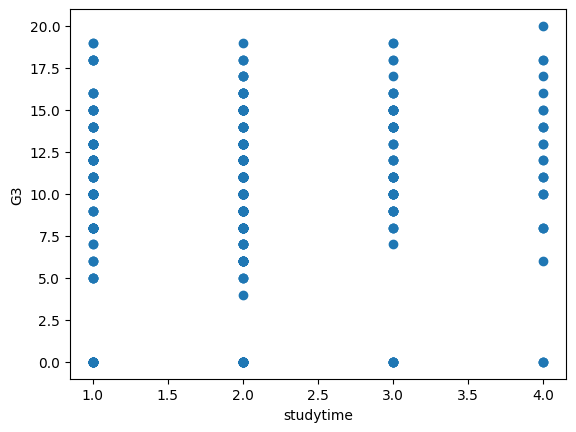

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded=files.upload()

df=pd.read_csv("student_data.csv")


x=df[["studytime","G1","G2"]]
y=df["G3"]


from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
schaler = StandardScaler()

schaler.fit(x_train)
x_train_scaled=schaler.transform(x_train)
x_test_scaled=schaler.transform(x_test)


from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)
pred_test=model.predict(x_test_scaled)




from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse=mean_squared_error(y_test,pred_test)
mae=mean_absolute_error(y_test,pred_test)
r2=r2_score(y_test,pred_test)

print("MSE: ",mse)
print("MAE: ",mae)
print("R2: ",r2)

w = model.coef_[0] # Assign the weight (coefficient) for the single feature
b = model.intercept_ # Assign the bias (intercept)

print("weights:" , w)
print("bias:" , b)

# Use the assigned w and b, and x_test_scaled for the prediction calculation
print("prediction: ",pred_test)



plt.scatter(x['studytime'],y)
plt.xlabel("studytime")
plt.ylabel("G3")
plt.show()

In [3]:
import pickle

pickle.dump(model,
open("student_model.pkl","wb"))
pickle.dump(x.columns,
open("model_columns.pkl","wb"))


In [4]:
from google.colab import files

files.download("student_model.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>